In [33]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

# Load preprocessed custom dataset
df = pd.read_parquet('preprocessed_custom_data.parquet')

# Convert categorical labels to binary format: benign = 0, attack = 1
df['Label'] = df['Label'].replace({'benign': 0, 'attack': 1})

# Define features (X) and target variable (y)
# Drop metadata and redundant columns
X = df.drop(columns=['Label', 'timestamp', 'attack'])
y = df['Label']

# Initialize and train a Decision Tree classifier for feature selection
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X, y)

# Optional: show top 20 most important features
importances = pd.Series(clf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(20)

print("Top 20 features based on importance:")
print(top_features)


/tmp/ipykernel_137208/4207284321.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Label'] = df['Label'].replace({'benign': 0, 'attack': 1})


Top 20 features based on importance:
syscalls_sys_exit_recvfrom              0.342406
bus_access_not_shared                   0.212311
qdisc_qdisc_dequeue                     0.062707
l2d_cache_wb                            0.060085
syscalls_sys_enter_sendto               0.042353
syscalls_sys_exit_rseq                  0.035911
net_netif_rx_entry                      0.032161
syscalls_sys_enter_waitid               0.028773
syscalls_sys_exit_execve                0.021672
writeback_writeback_mark_inode_dirty    0.019831
sched_sched_process_free                0.019828
node-loads                              0.011563
syscalls_sys_exit_write                 0.010635
sched_sched_process_wait                0.009700
l1d_cache_wb_clean                      0.009340
bus-cycles                              0.008303
dTLB-load-misses                        0.004879
syscalls_sys_exit_getpid                0.004856
iTLB-load-misses                        0.004549
node-stores                     

Confusion matrix:
[[ 934    0]
 [   0 5860]]


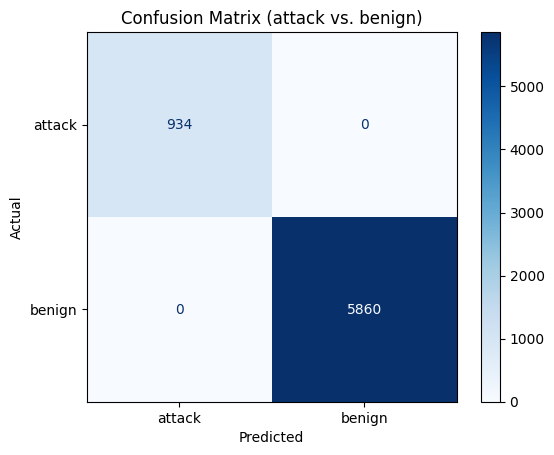

In [34]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Step 1: Generate predictions on the same dataset (for internal validation only)
y_pred = clf.predict(X)

# Order: attack (1) first, then benign (0)
labels = [1, 0]

# Compute confusion matrix with explicit label order
cm = confusion_matrix(y, y_pred, labels=labels)
print("Confusion matrix:")
print(cm)

# Display with appropriate labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['attack', 'benign'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix (attack vs. benign)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


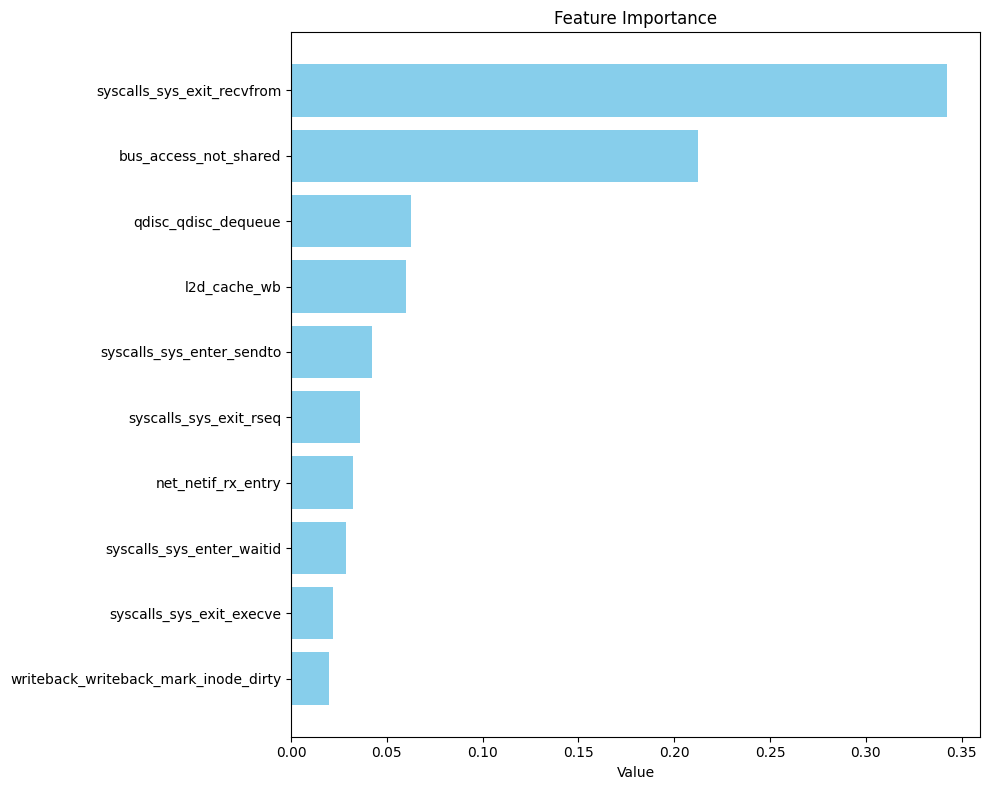

In [35]:
import matplotlib.pyplot as plt

# Assume top_features is a Pandas Series, for example:
# top_features = pd.Series({...})

features = top_features[:10].index
values = top_features[:10].values

plt.figure(figsize=(10, 8))
plt.barh(features, values, color='skyblue')
plt.xlabel('Value')
plt.title('Feature Importance')
plt.gca().invert_yaxis()  # To show the largest feature at the top
plt.tight_layout()
plt.savefig('plots/feature_importance.png')
plt.show()
plt.close()


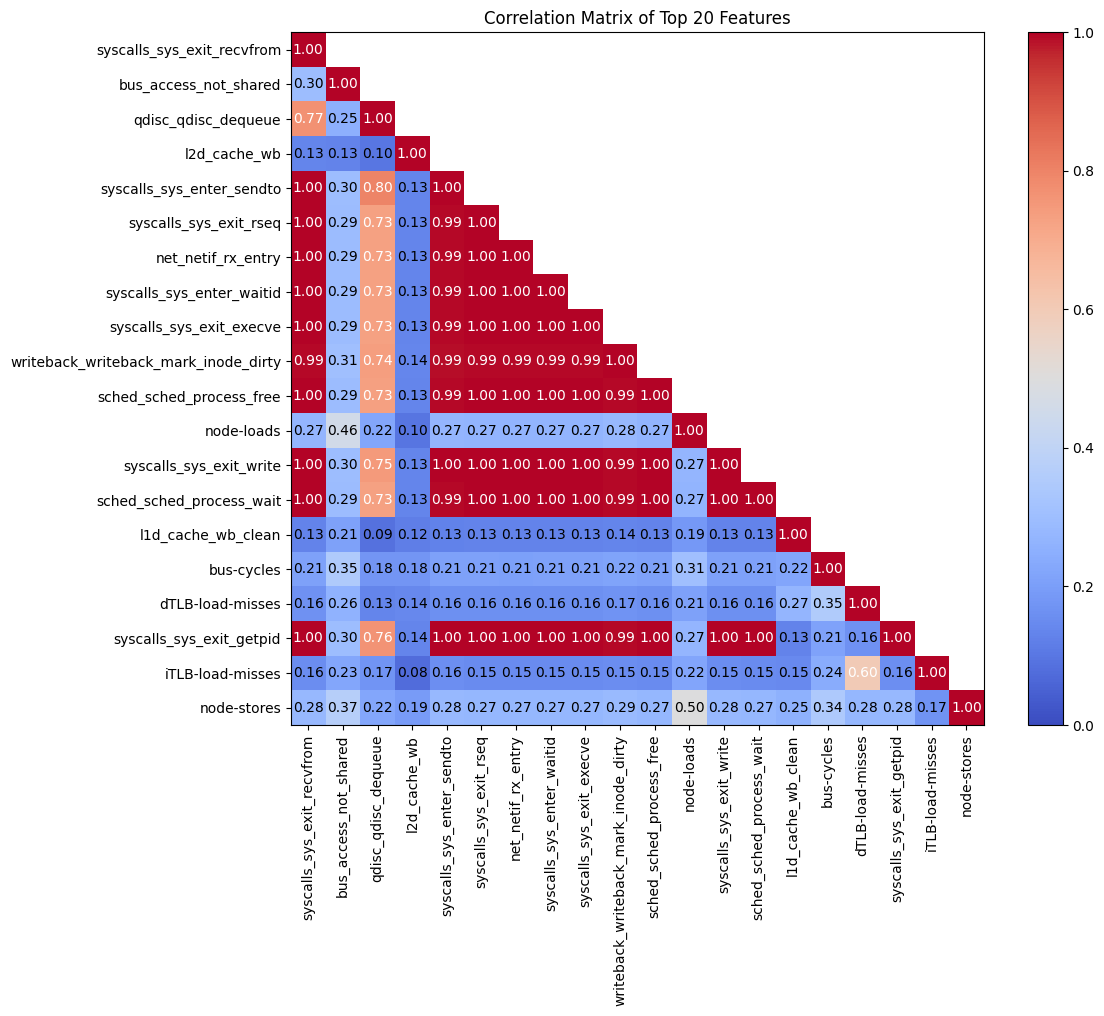

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Verwende die Top 20 Features aus deinem vorherigen Schritt
top20_features = top_features.index

# Erstelle Subset mit den Top 20 Features aus X
X_top20 = X[top20_features]

# Berechne Korrelationsmatrix
corr_matrix = X_top20.corr()

# Erstelle Maske für obere Dreiecksmatrix
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

# Wende Maske an (setzt obere Dreiecksmatrix auf NaN, damit nur untere sichtbar ist)
corr_matrix_masked = corr_matrix.mask(mask)

plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix_masked, cmap='coolwarm', interpolation='nearest', vmin=0, vmax=1)
plt.colorbar()
plt.title("Correlation Matrix of Top 20 Features")

# Achsenbeschriftung
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

# Korrelationswerte nur in der unteren Dreiecksmatrix anzeigen
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        if i >= j:
            value = corr_matrix.iloc[i, j]
            color = 'white' if abs(value) > 0.5 else 'black'
            plt.text(j, i, f'{value:.2f}', ha='center', va='center', color=color)

plt.tight_layout()
plt.savefig('plots/corrlationMatrix_DT_firstrun.png')
plt.show()


In [37]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Remove strongly correlated features (>0.99 correlation),
# always dropping the one with lower importance

# X: your DataFrame with features
# importances: a Pandas Series with feature names as index and their importance values

# Calculate the absolute correlation matrix
corr_matrix = X.corr().abs()
# Select upper triangle of the matrix (without the diagonal)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = set()  # Set to hold features to drop

# Go through each feature in the upper triangle matrix
for col in upper_tri.columns:
    # Find features highly correlated with 'col'
    high_corr_feats = upper_tri.index[upper_tri[col] > 0.99].tolist()
    for feat in high_corr_feats:
        # Remove the feature with lower importance
        if importances[feat] < importances[col]:
            to_drop.add(feat)
        else:
            to_drop.add(col)

# Create reduced feature set, dropping the selected features
X_reduced = X.drop(columns=to_drop)

# 2. Train a Decision Tree with reduced features
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_reduced, y)

# 3. Extract feature importances and select top 20
importances = pd.Series(clf.feature_importances_, index=X_reduced.columns)
top_features = importances.sort_values(ascending=False).head(20)

print("Top 20 features after removing highly correlated ones:")
print(top_features)


Top 20 features after removing highly correlated ones:
syscalls_sys_exit_recvfrom    0.352106
bus_access_not_shared         0.215104
tcp_tcp_retransmit_skb        0.092647
jbd2_jbd2_checkpoint_stats    0.062707
l2d_cache_wb                  0.061214
jbd2_jbd2_shrink_count        0.035911
qdisc_qdisc_dequeue           0.032766
syscalls_sys_enter_accept4    0.032161
syscalls_sys_enter_accept     0.021672
node-loads                    0.011563
bus-cycles                    0.008303
iTLB-load-misses              0.007308
dTLB-load-misses              0.007004
node-stores                   0.006526
l1d_cache_wb_clean            0.006361
syscalls_sys_enter_fchmod     0.004856
dp_spec                       0.004577
l2d_cache_refill_rd           0.003414
br_mis_pred                   0.002622
mem_access                    0.002483
dtype: float64


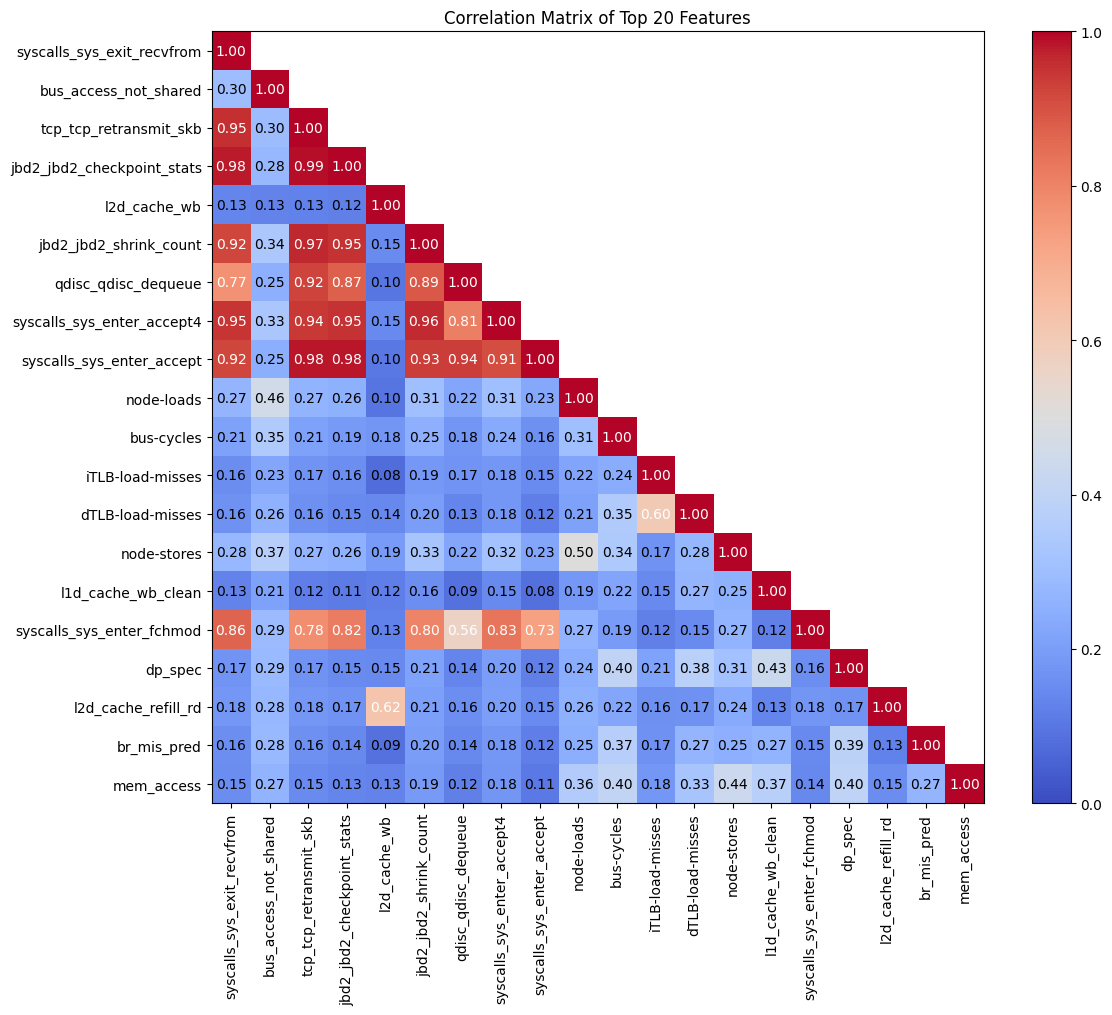

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Verwende die Top 20 Features aus deinem vorherigen Schritt
top20_features = top_features.index

# Erstelle Subset mit den Top 20 Features aus X
X_top20 = X[top20_features]

# Berechne Korrelationsmatrix
corr_matrix = X_top20.corr()

# Erstelle Maske für obere Dreiecksmatrix
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

# Wende Maske an (setzt obere Dreiecksmatrix auf NaN, damit nur untere sichtbar ist)
corr_matrix_masked = corr_matrix.mask(mask)

plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix_masked, cmap='coolwarm', interpolation='nearest', vmin=0, vmax=1)
plt.colorbar()
plt.title("Correlation Matrix of Top 20 Features")

# Achsenbeschriftung
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

# Korrelationswerte nur in der unteren Dreiecksmatrix anzeigen
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        if i >= j:
            value = corr_matrix.iloc[i, j]
            color = 'white' if abs(value) > 0.5 else 'black'
            plt.text(j, i, f'{value:.2f}', ha='center', va='center', color=color)

plt.tight_layout()
plt.savefig('plots/corrlationMatrix_DT_secondrun.png')
plt.show()


In [7]:
import joblib

# Modell speichern
joblib.dump(model, 'decision_tree_model.joblib')


['decision_tree_model.joblib']